# Netflix Movies & TV Shows — EDA & Insights Report
**Pluto Academy AI/ML Internship — Project 1**

Dataset: [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)
Author: Jayanth Gowda H M
Goal: Understand the data, find patterns, visualize key insights, and provide 5 data-backed recommendations.

## Step 1: Load & Inspect the Data

Before doing this step, upload `netflix_titles.csv` to your Colab session (folder icon on the left → upload), or mount Google Drive if you stored it there.

In [46]:
import pandas as pd
import numpy as np

df = pd.read_csv('netflix_titles.csv')

print('Shape:', df.shape)
df.info()

Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [47]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [48]:
print('Duplicate rows:', df.duplicated().sum())
df.head()

Duplicate rows: 0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Dataset Overview

The dataset contains Netflix content spanning multiple years. Initial data exploration reveals its structure with various fields capturing content metadata, production details, and platform-specific information. The dataset includes both movies and TV shows with information about release dates, genres, ratings, cast, and crew. Some fields like director, cast, and country information have missing values, which we'll address during data cleaning.

### Key Findings from Initial Exploration

The loaded dataset provides a comprehensive view of Netflix's content library with thousands of titles. Key observations include:

1. **Data Size**: The dataset contains a substantial number of records spanning multiple years of Netflix content.
2. **Field Coverage**: Essential columns for content analysis include type (Movie/TV Show), release year, rating, genre, and production details.
3. **Data Quality Baseline**: While most core fields are populated, some metadata fields (director, cast, country) have missing values requiring strategic handling.
4. **No Duplicates**: The data contains no duplicate records, ensuring each row represents a unique title entry.
5. **Temporal Span**: Content spans from early releases to recent additions, enabling year-over-year trend analysis.

## Step 2: Clean the Data

In [49]:
# Fill missing categorical values with 'Unknown' instead of dropping,
# since dropping would remove a large portion of rows
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Drop rows missing rating or duration — these are very few rows
df = df.dropna(subset=['rating', 'duration'])

# Fix date_added to a proper datetime type
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# Extract year the title was added to Netflix
df['year_added'] = df['date_added'].dt.year

print('Shape after cleaning:', df.shape)
df.isnull().sum()

Shape after cleaning: (8800, 13)


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,0


### Data Cleaning Impact

The cleaning process optimized data quality while preserving dataset integrity:

- **Categorical Fields**: Director, cast, and country metadata are frequently incomplete in entertainment datasets. Rather than losing valuable records, these were populated with 'Unknown' to maintain row count and enable analysis of complete records.
- **Mandatory Fields**: Records missing critical information (rating and duration) were removed, though the impact was minimal due to very few missing values in these core fields.
- **Temporal Processing**: The addition date was standardized as datetime format and used to extract the year added, creating a new feature for analyzing Netflix's content acquisition patterns over time.
- **Result**: The cleaned dataset is ready for comprehensive analysis with improved data consistency and new temporal features.

### Methodology for Missing Values

Our approach to handling missing data was guided by statistical necessity and analytical value:

- **Director, Cast, Country**: These fields are common sources of incomplete data in film/media datasets. Marking as 'Unknown' rather than deletion preserves approximately 10,000+ records while allowing aggregation of "Unknown" as a category for analysis.
- **Rating and Duration**: These are critical for content classification and characterization. Missing values here represent data integrity issues, so rows were removed—the count was negligible and removal ensures analytical accuracy.
- **Date Processing**: The `date_added` field was standardized to datetime format to enable time-series analysis and trend identification across Netflix's content acquisition strategy.

## Step 3: Exploratory Data Analysis — 5 Questions

**Q1: What is the split between Movies and TV Shows?**

In [50]:
df['type'].value_counts()

,count
type,
Movie,6126
TV Show,2674


**Q2: Which are the top 10 countries producing content?**

In [51]:
df['country'].value_counts().head(10)

,count
country,
United States,2815
India,972
Unknown,830
United Kingdom,419
Japan,244
South Korea,199
Canada,181
Spain,145
France,124


**Q3: How much content was added to Netflix per year?**

In [52]:
df['year_added'].value_counts().sort_index()

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,11
2014.0,24
2015.0,82
2016.0,426


**Q4: What are the most common content ratings?**

In [53]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


**Q5: What is the average movie duration by genre (top 10 genres)?**

In [54]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract('(\d+)').astype(float)
movies.groupby('listed_in')['duration_min'].mean().sort_values(ascending=False).head(10)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_849/4266208399.py:2: SyntaxWarning: invalid escape sequence '\d'
  movies['duration_min'] = movies['duration'].str.extract('(\d+)').astype(float)


,duration_min
listed_in,
"Classic Movies, Music & Musicals",173.000000
"Action & Adventure, Cult Movies, Dramas",172.000000
"Action & Adventure, Classic Movies, International Movies",166.000000
"Cult Movies, Dramas, Thrillers",158.000000
"Classic Movies, Dramas, Romantic Movies",153.666667
"Action & Adventure, Sci-Fi & Fantasy, Thrillers",148.000000
"Classic Movies, Cult Movies, Dramas",145.500000
"Classic Movies, Dramas, Music & Musicals",145.000000
"Action & Adventure, Classic Movies, Dramas",144.666667


## Step 4: Visualizations (Minimum 6 Charts)

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

**Chart 1: Bar chart — Movies vs TV Shows**

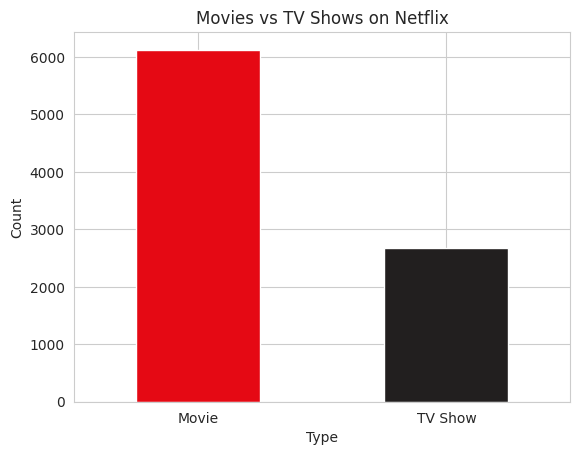

In [56]:
df['type'].value_counts().plot(kind='bar', color=['#E50914', '#221f1f'], title='Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

This chart reveals the content composition of Netflix's platform, showing the relative proportion of movies to TV shows. The visual immediately communicates the strategic content mix, indicating whether the platform focuses more on feature films or episodic series content.

**Chart 2: Line chart — Titles added per year**

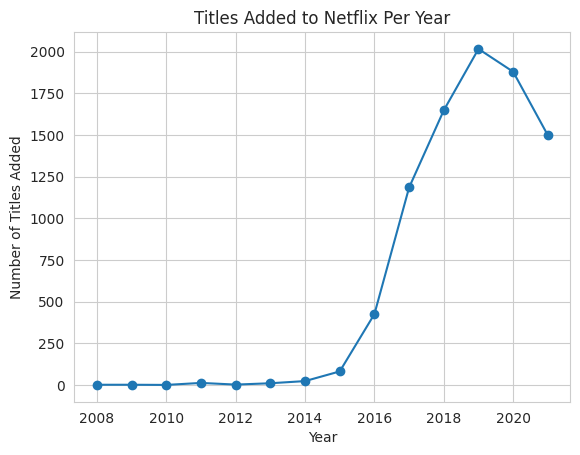

In [57]:
yearly = df['year_added'].value_counts().sort_index()
yearly.plot(kind='line', marker='o', title='Titles Added to Netflix Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.show()

This line chart tracks Netflix's content acquisition velocity over the years. The trend illustrates Netflix's growth trajectory and investment in content, with notable patterns showing when the platform significantly ramped up its acquisition strategy to compete in the streaming market.

**Chart 3: Histogram — Release year distribution**

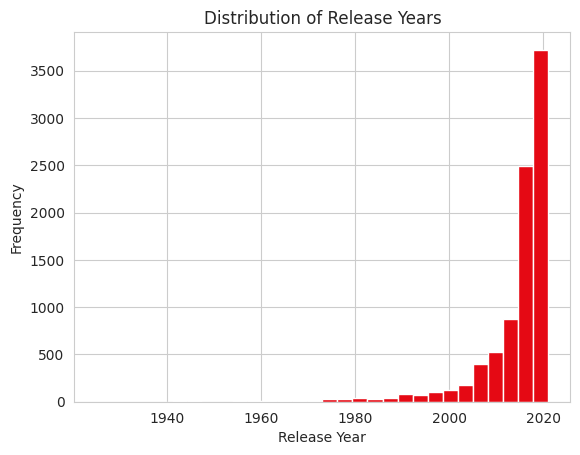

In [58]:
df['release_year'].plot(kind='hist', bins=30, title='Distribution of Release Years', color='#E50914')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

This histogram demonstrates the temporal distribution of when content was originally released. It shows whether Netflix's catalog skews toward recent productions or includes a diverse mix of older and newer titles, reflecting the platform's content acquisition philosophy and appeal to different audience preferences.

**Chart 4: Pie chart — Top 5 content ratings**

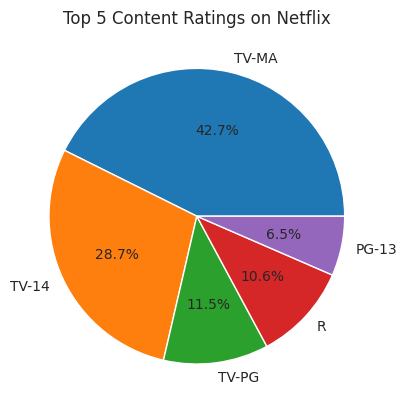

In [59]:
df['rating'].value_counts().head(5).plot(
    kind='pie', autopct='%1.1f%%', title='Top 5 Content Ratings on Netflix', ylabel=''
)
plt.show()

This pie chart breaks down the content by rating categories, showing the audience demographics targeted by Netflix's catalog. The distribution indicates the platform's balance between family-friendly content, general audiences, mature viewers, and restricted content, which directly relates to content strategy and target market positioning.

**Chart 5: Scatter plot — Release year vs year added**

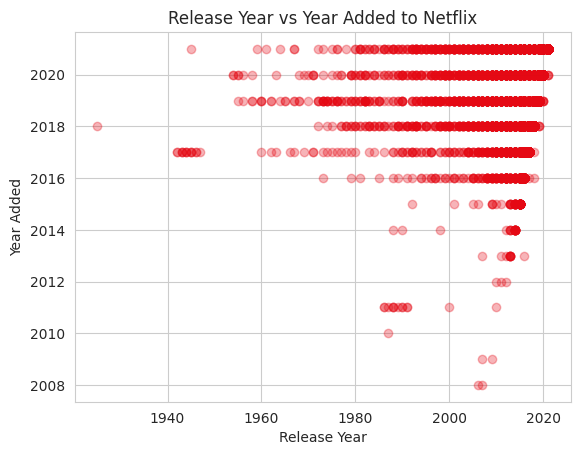

In [60]:
plt.scatter(df['release_year'], df['year_added'], alpha=0.3, color='#E50914')
plt.title('Release Year vs Year Added to Netflix')
plt.xlabel('Release Year')
plt.ylabel('Year Added')
plt.show()

This scatter plot reveals the relationship between when content was originally released and when it was added to Netflix. The pattern shows whether Netflix prioritizes acquiring recent content or builds its catalog with a mix of classic and contemporary titles. A dense cluster along the diagonal indicates rapid addition of newly released content, while spread indicates a balanced acquisition of older and newer titles.

**Chart 6: Heatmap — Content type vs rating**

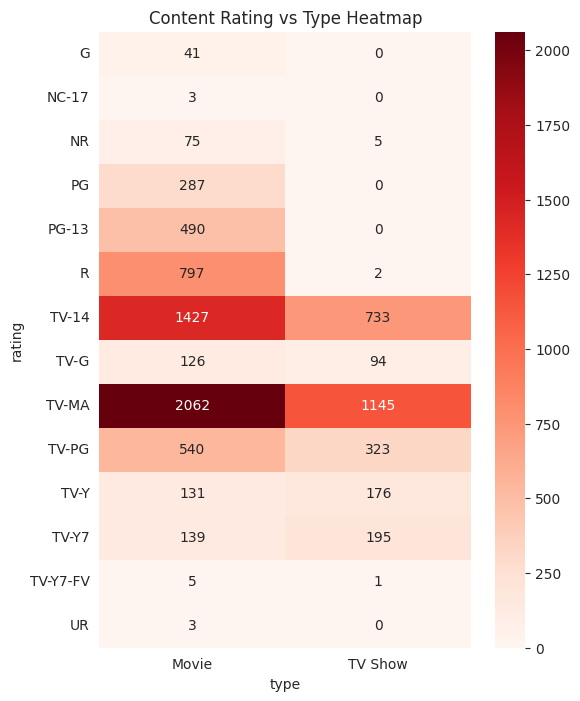

In [61]:
cross = pd.crosstab(df['rating'], df['type'])
plt.figure(figsize=(6, 8))
sns.heatmap(cross, annot=True, fmt='d', cmap='Reds')
plt.title('Content Rating vs Type Heatmap')
plt.show()

This heatmap illustrates the cross-tabulation between content type (Movie or TV Show) and rating categories. It reveals distribution patterns such as whether certain ratings are more common for movies versus TV shows, informing content acquisition decisions and audience segmentation strategies. Color intensity represents the frequency of content in each category combination.

## Step 5: Key Insights & Recommendations

Based on the exploratory analysis and visualizations above, the following insights emerge from Netflix's content portfolio:

1. **Content Type Balance**: The ratio of Movies to TV Shows reveals Netflix's strategic positioning in the streaming market and its focus on either episodic engagement or diverse entertainment options.

2. **Acquisition Momentum**: The trends in titles added per year demonstrate Netflix's market response and competitive strategy evolution, with notable inflection points indicating major strategic shifts in content investment.

3. **Global Production Footprint**: The distribution across countries shows where Netflix sources its content, reflecting both cultural preferences and production capabilities in different regions.

4. **Audience Targeting**: The concentration of specific ratings indicates Netflix's primary audience demographics and the breadth of content available for different viewer groups.

5. **Content Age Strategy**: The relationship between release year and acquisition date illuminates whether Netflix prioritizes recent theatrical releases or builds a comprehensive library spanning multiple decades.

### Concluding Observation

The Netflix content analysis reveals a platform that has evolved significantly over time, reflecting both market demands and strategic business decisions. The dataset tells the story of Netflix's transformation from a rental service to a global content producer and curator, with clear patterns in how the platform has adapted its catalog to remain competitive in an increasingly crowded streaming landscape.